## Notebook 01 — Data Collection

This notebook pulls daily OHLCV price data for all assets in the Precursor universe via `yfinance`, validates the data, and saves cleaned CSVs to `data/raw/`.

**Asset universe:**
- Commodities: WTI Crude (`CL=F`), Brent Crude (`BZ=F`), Copper (`HG=F`), Natural Gas (`NG=F`), Gold (`GC=F`)
- Equity ETFs: Energy (`XLE`), Materials (`XLB`), Gold Miners (`GDX`)

**Date range:** 2010-01-01 to present

---
### 1. Imports

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import os
from datetime import datetime

print(f"yfinance version : {yf.__version__}")
print(f"pandas version   : {pd.__version__}")
print(f"Run timestamp    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

yfinance version : 1.4.0
pandas version   : 3.0.3
Run timestamp    : 2026-05-24 00:27:16


---
### 2. Config

In [2]:
# --- Asset universe ---
ASSETS = {
    # Commodities
    "WTI"  : "CL=F",
    "Brent": "BZ=F",
    "Copper": "HG=F",
    "NatGas": "NG=F",
    "Gold"  : "GC=F",
    # Equity ETFs
    "XLE"  : "XLE",
    "XLB"  : "XLB",
    "GDX"  : "GDX",
}

COMMODITIES = ["WTI", "Brent", "Copper", "NatGas", "Gold"]
EQUITIES    = ["XLE", "XLB", "GDX"]

# Hypothesised spillover pairs (commodity -> equity)
PAIRS = [
    ("WTI",    "XLE"),
    ("Brent",  "XLE"),
    ("Copper", "XLB"),
    ("Gold",   "GDX"),
    ("NatGas", "XLE"),
]

# Date range
START_DATE = "2010-01-01"
END_DATE   = datetime.today().strftime("%Y-%m-%d")

# Output path
RAW_DIR = os.path.join("..", "data", "raw")
os.makedirs(RAW_DIR, exist_ok=True)

print(f"Date range : {START_DATE} → {END_DATE}")
print(f"Assets     : {len(ASSETS)}")
print(f"Output dir : {os.path.abspath(RAW_DIR)}")

Date range : 2010-01-01 → 2026-05-24
Assets     : 8
Output dir : c:\Users\bhavd\Projects\precursor\data\raw


---
### 3. Download Price Data

In [3]:
raw_data = {}

for name, ticker in ASSETS.items():
    print(f"Downloading {name} ({ticker})...", end=" ")
    try:
        df = yf.download(
            ticker,
            start=START_DATE,
            end=END_DATE,
            auto_adjust=True,
            progress=False
        )
        if df.empty:
            print(f"WARNING: no data returned for {ticker}")
            continue

        # Flatten MultiIndex columns if present
        if isinstance(df.columns, pd.MultiIndex):
            df.columns = df.columns.get_level_values(0)

        df.index = pd.to_datetime(df.index)
        raw_data[name] = df
        print(f"{len(df)} rows | {df.index[0].date()} → {df.index[-1].date()}")

    except Exception as e:
        print(f"ERROR: {e}")

print(f"\nSuccessfully downloaded: {list(raw_data.keys())}")


Successfully downloaded: ['WTI', 'Brent', 'Copper', 'NatGas', 'Gold', 'XLE', 'XLB', 'GDX']


---
### 4. Validate Data

In [4]:
print("=" * 60)
print(f"{'Asset':<10} {'Rows':>6} {'Start':>12} {'End':>12} {'NaN (Close)':>12}")
print("=" * 60)

for name, df in raw_data.items():
    n_rows     = len(df)
    start      = df.index[0].date()
    end        = df.index[-1].date()
    nan_close  = df["Close"].isna().sum()
    print(f"{name:<10} {n_rows:>6} {str(start):>12} {str(end):>12} {nan_close:>12}")

print("=" * 60)

Asset        Rows        Start          End  NaN (Close)
WTI          4122   2010-01-04   2026-05-22            0
Brent        4091   2010-01-04   2026-05-22            0
Copper       4122   2010-01-04   2026-05-22            0
NatGas       4123   2010-01-04   2026-05-22            0
Gold         4121   2010-01-04   2026-05-22            0
XLE          4122   2010-01-04   2026-05-22            0
XLB          4122   2010-01-04   2026-05-22            0
GDX          4122   2010-01-04   2026-05-22            0


In [5]:
# Check coverage overlap — all assets should share a common trading calendar
close_prices = pd.DataFrame({
    name: df["Close"] for name, df in raw_data.items()
})

print(f"Combined DataFrame shape : {close_prices.shape}")
print(f"Date range               : {close_prices.index[0].date()} → {close_prices.index[-1].date()}")
print(f"\nMissing values per asset:")
print(close_prices.isna().sum())
print(f"\nRows with ANY missing value : {close_prices.isna().any(axis=1).sum()}")
print(f"Rows fully complete         : {close_prices.dropna().shape[0]}")

Combined DataFrame shape : (4125, 8)
Date range               : 2010-01-04 → 2026-05-22

Missing values per asset:
WTI        3
Brent     34
Copper     3
NatGas     2
Gold       4
XLE        3
XLB        3
GDX        3
dtype: int64

Rows with ANY missing value : 38
Rows fully complete         : 4087


---
### 5. Save Raw Data

We save two formats:
- **Per-asset CSV** — full OHLCV for each ticker, for reference
- **Combined close prices CSV** — the primary input for all downstream notebooks

In [6]:
# Save individual OHLCV files
for name, df in raw_data.items():
    path = os.path.join(RAW_DIR, f"{name.lower()}_ohlcv.csv")
    df.to_csv(path)
    print(f"Saved: {path}")

# Save combined close prices
close_path = os.path.join(RAW_DIR, "close_prices.csv")
close_prices.to_csv(close_path)
print(f"\nSaved combined close prices: {close_path}")
print(f"Shape: {close_prices.shape}")

Saved: ..\data\raw\wti_ohlcv.csv
Saved: ..\data\raw\brent_ohlcv.csv
Saved: ..\data\raw\copper_ohlcv.csv
Saved: ..\data\raw\natgas_ohlcv.csv
Saved: ..\data\raw\gold_ohlcv.csv
Saved: ..\data\raw\xle_ohlcv.csv
Saved: ..\data\raw\xlb_ohlcv.csv
Saved: ..\data\raw\gdx_ohlcv.csv

Saved combined close prices: ..\data\raw\close_prices.csv
Shape: (4125, 8)


---
### 6. Quick Sanity Plot

Normalised price series (rebased to 100 at start) to visually confirm all data loaded correctly.

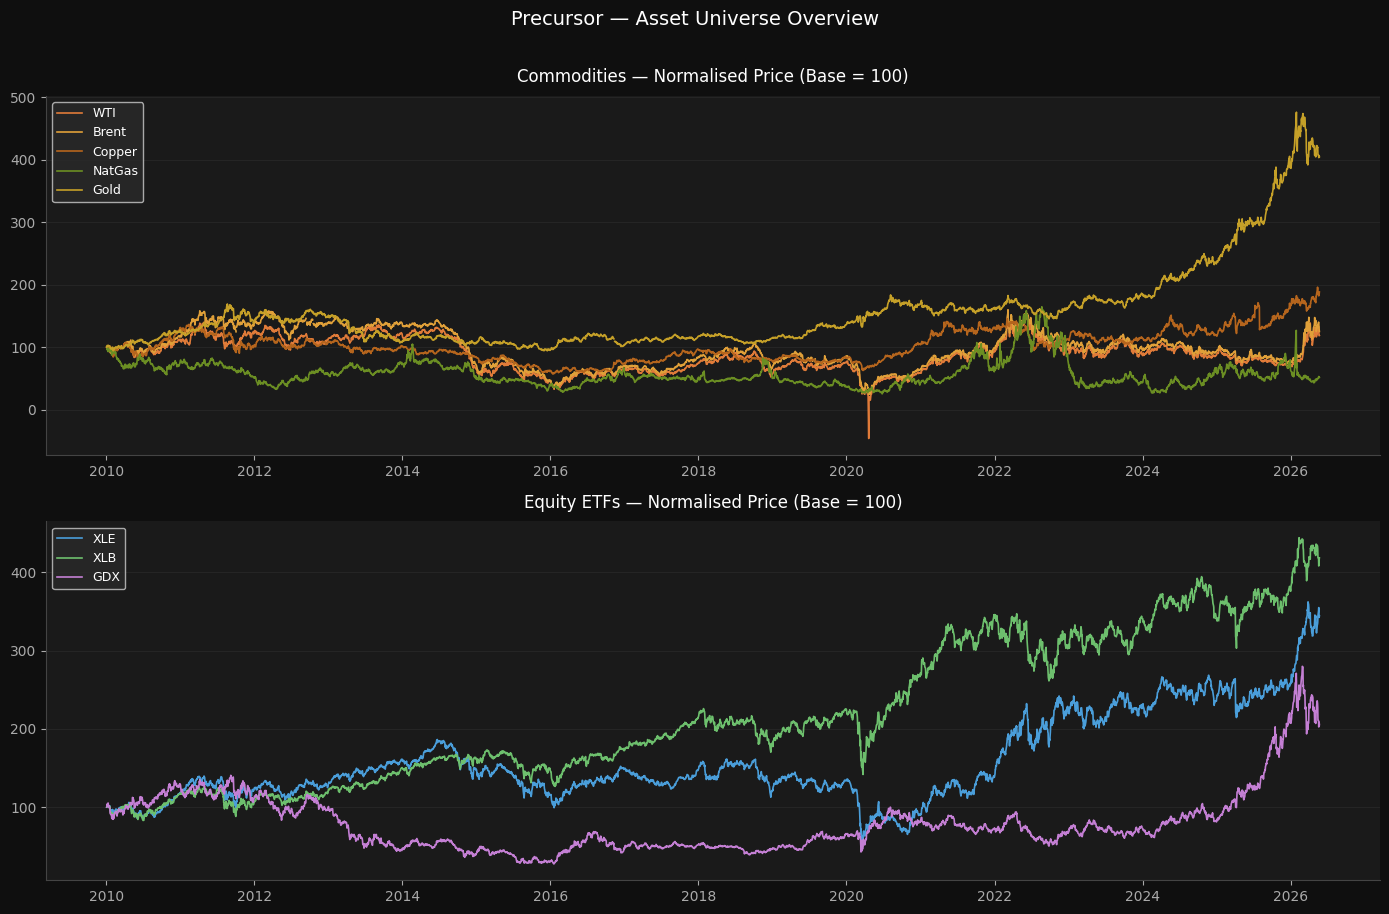

Figure saved: ..\figures\01_normalised_prices.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

fig, axes = plt.subplots(2, 1, figsize=(14, 9), facecolor="#0f0f0f")

colors_comm = ["#e07b39", "#e0a039", "#b5651d", "#6b8e23", "#c5a028"]
colors_eq   = ["#4a9eda", "#6dbf6d", "#c47fd4"]

# Normalise to 100
normed = close_prices.div(close_prices.iloc[0]) * 100

# Commodities
ax1 = axes[0]
ax1.set_facecolor("#1a1a1a")
for i, col in enumerate(COMMODITIES):
    if col in normed.columns:
        ax1.plot(normed.index, normed[col], label=col, color=colors_comm[i], linewidth=1.2)
ax1.set_title("Commodities — Normalised Price (Base = 100)", color="white", fontsize=12, pad=10)
ax1.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=9)
ax1.tick_params(colors="#aaaaaa")
ax1.spines[["top","right"]].set_visible(False)
ax1.spines[["bottom","left"]].set_color("#444444")
ax1.yaxis.label.set_color("#aaaaaa")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.grid(axis="y", color="#2a2a2a", linewidth=0.5)

# Equities
ax2 = axes[1]
ax2.set_facecolor("#1a1a1a")
for i, col in enumerate(EQUITIES):
    if col in normed.columns:
        ax2.plot(normed.index, normed[col], label=col, color=colors_eq[i], linewidth=1.2)
ax2.set_title("Equity ETFs — Normalised Price (Base = 100)", color="white", fontsize=12, pad=10)
ax2.legend(facecolor="#2a2a2a", labelcolor="white", fontsize=9)
ax2.tick_params(colors="#aaaaaa")
ax2.spines[["top","right"]].set_visible(False)
ax2.spines[["bottom","left"]].set_color("#444444")
ax2.yaxis.label.set_color("#aaaaaa")
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax2.grid(axis="y", color="#2a2a2a", linewidth=0.5)

fig.suptitle("Precursor — Asset Universe Overview", color="white", fontsize=14, y=1.01)
plt.tight_layout()

fig_path = os.path.join("..", "figures", "01_normalised_prices.png")
os.makedirs(os.path.dirname(fig_path), exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight", facecolor="#0f0f0f")
plt.show()
print(f"Figure saved: {fig_path}")

---
### 7. Summary

| Output | Path |
|---|---|
| Per-asset OHLCV | `data/raw/{name}_ohlcv.csv` |
| Combined close prices | `data/raw/close_prices.csv` |
| Normalised price plot | `figures/01_normalised_prices.png` |